# Analisis Exploratorio

### Librerias y datos

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
!unzip OneDrive_2026-03-25.zip
!mv -f Datasets\ Tarea\ \(p├║blico\) Datos

Archive:  OneDrive_2026-03-25.zip
 extracting: Datasets Tarea (p├║blico)/competicion_ranking.json  
 extracting: Datasets Tarea (p├║blico)/competicion_rating.txt  
 extracting: Datasets Tarea (p├║blico)/wikimedia_image_embeddings.npy  
 extracting: Datasets Tarea (p├║blico)/wikimedia_item_id_to_idx.npy  
 extracting: Datasets Tarea (p├║blico)/wikimedia_train.csv  
 extracting: Datasets Tarea (p├║blico)/wikimedia_validation.csv  
 extracting: Datasets Tarea (p├║blico)/ydata_artists.txt  
 extracting: Datasets Tarea (p├║blico)/ydata_train.txt  
 extracting: Datasets Tarea (p├║blico)/ydata_val.txt  


In [ ]:
yahoo_train = pd.read_csv("Datos/ydata_train.txt", sep="\t", header=None)
yahoo_train.columns = ["user_id", "artist_id", "rating"]

yahoo_artists = pd.read_csv("Datos/ydata_artists.txt", sep="\t", header=None)
yahoo_artists.columns = ["artist_id", "artist_name", "genre"]

yahoo_val = pd.read_csv("Datos/ydata_val.txt", sep="\t", header=None)
yahoo_val.columns = ["user_id", "artist_id", "rating"]

wiki_train = pd.read_csv("Datos/wikimedia_train.csv")

wiki_val = pd.read_csv("Datos/wikimedia_validation.csv")

## Datos Yahoo! Music

### Distribucion: Numero de ratings

In [ ]:
yahoo_train.describe()  # lo interesante de esto son los datos para rating

,user_id,artist_id,rating
count,5.346370e+05,5.346370e+05,534637.000000
mean,9.514221e+05,1.030821e+06,19.771927
std,5.609952e+05,2.839402e+04,34.829398
min,1.430000e+02,1.000004e+06,0.000000
25%,4.681470e+05,1.011139e+06,0.000000
50%,9.454190e+05,1.022601e+06,0.000000
75%,1.429002e+06,1.036736e+06,30.000000
max,1.948075e+06,1.100995e+06,255.000000


In [ ]:
yahoo_val.describe()

,user_id,artist_id,rating
count,1.524240e+05,1.524240e+05,152424.000000
mean,9.513846e+05,1.030885e+06,19.833051
std,5.609833e+05,2.845525e+04,34.917863
min,1.430000e+02,1.000004e+06,0.000000
25%,4.681470e+05,1.011312e+06,0.000000
50%,9.454190e+05,1.022740e+06,0.000000
75%,1.429002e+06,1.036607e+06,30.000000
max,1.948075e+06,1.100995e+06,255.000000


In [ ]:
# numero de ratings por usuario
items_per_user = yahoo_train.groupby("user_id")["rating"].count()
# numero de ratings por artista
users_per_item = yahoo_train.groupby("artist_id")["rating"].count()

print(items_per_user.describe(), end="\n\n")
print(users_per_item.describe())

count    2549.000000
mean      209.743821
std        51.529677
min       128.000000
25%       171.000000
50%       195.000000
75%       236.000000
max       392.000000
Name: rating, dtype: float64

count    2631.000000
mean      203.206765
std        61.931667
min        98.000000
25%       152.500000
50%       185.000000
75%       248.500000
max       383.000000
Name: rating, dtype: float64


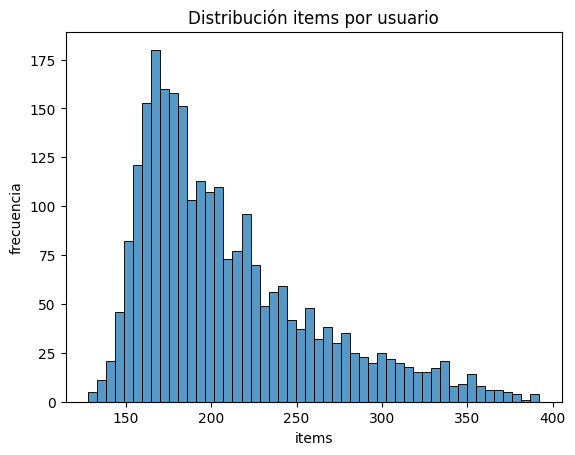

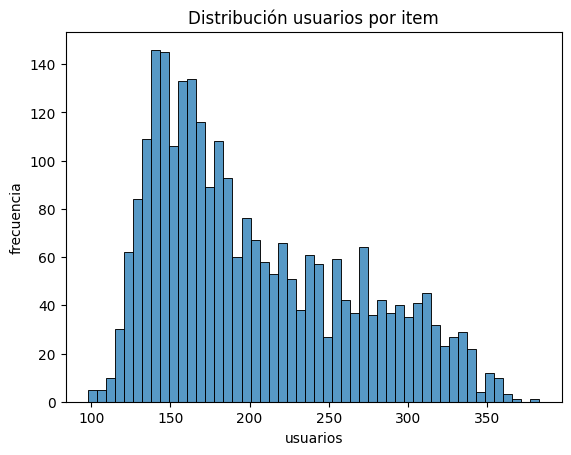

In [ ]:
plt.figure()
sns.histplot(items_per_user, bins=50)
plt.title("Distribución items por usuario")
plt.xlabel("items")
plt.ylabel("frecuencia")
plt.show()

plt.figure()
sns.histplot(users_per_item, bins=50)
plt.title("Distribución usuarios por item")
plt.xlabel("usuarios")
plt.ylabel("frecuencia")
plt.show()

### Distribucion: Ratings promedio

In [ ]:
# rating promedio por usuario
mean_rating_per_user = yahoo_train.groupby("user_id")["rating"].mean()

# rating promedio por artista
mean_rating_per_item = yahoo_train.groupby("artist_id")["rating"].mean()

print(mean_rating_per_user.describe(), end="\n\n")
print(mean_rating_per_item.describe())

count    2549.000000
mean       20.352879
std        24.717332
min         0.000000
25%         4.326923
50%        10.613924
75%        28.636364
max       250.843575
Name: rating, dtype: float64

count    2631.000000
mean       18.409311
std         7.383782
min         3.045455
25%        12.821632
50%        17.525836
75%        22.678598
max        52.146853
Name: rating, dtype: float64


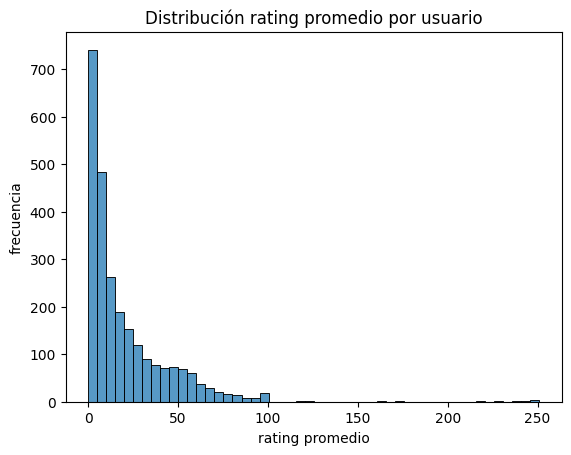

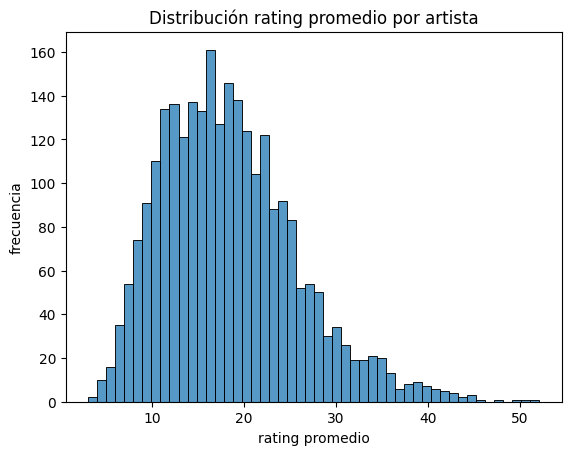

In [ ]:
plt.figure()
sns.histplot(mean_rating_per_user, bins=50)
plt.title("Distribución rating promedio por usuario")
plt.xlabel("rating promedio")
plt.ylabel("frecuencia")
plt.show()

sns.histplot(mean_rating_per_item, bins=50)
plt.title("Distribución rating promedio por artista")
plt.xlabel("rating promedio")
plt.ylabel("frecuencia")
plt.show()

### Distribucion: Ratings

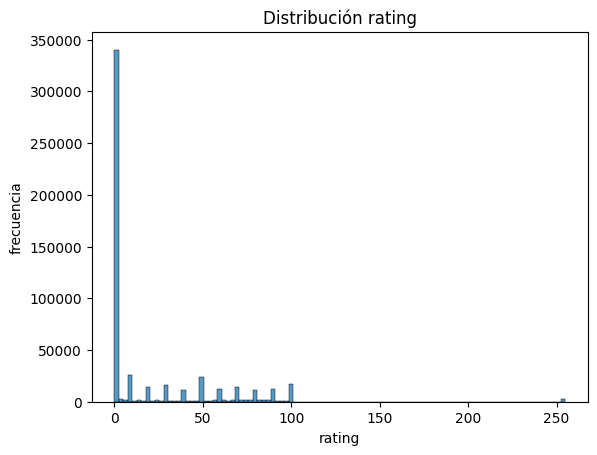

In [ ]:
plt.figure()
sns.histplot(yahoo_train["rating"], bins=101)
plt.title("Distribución rating")
plt.xlabel("rating")
plt.ylabel("frecuencia")
plt.show()

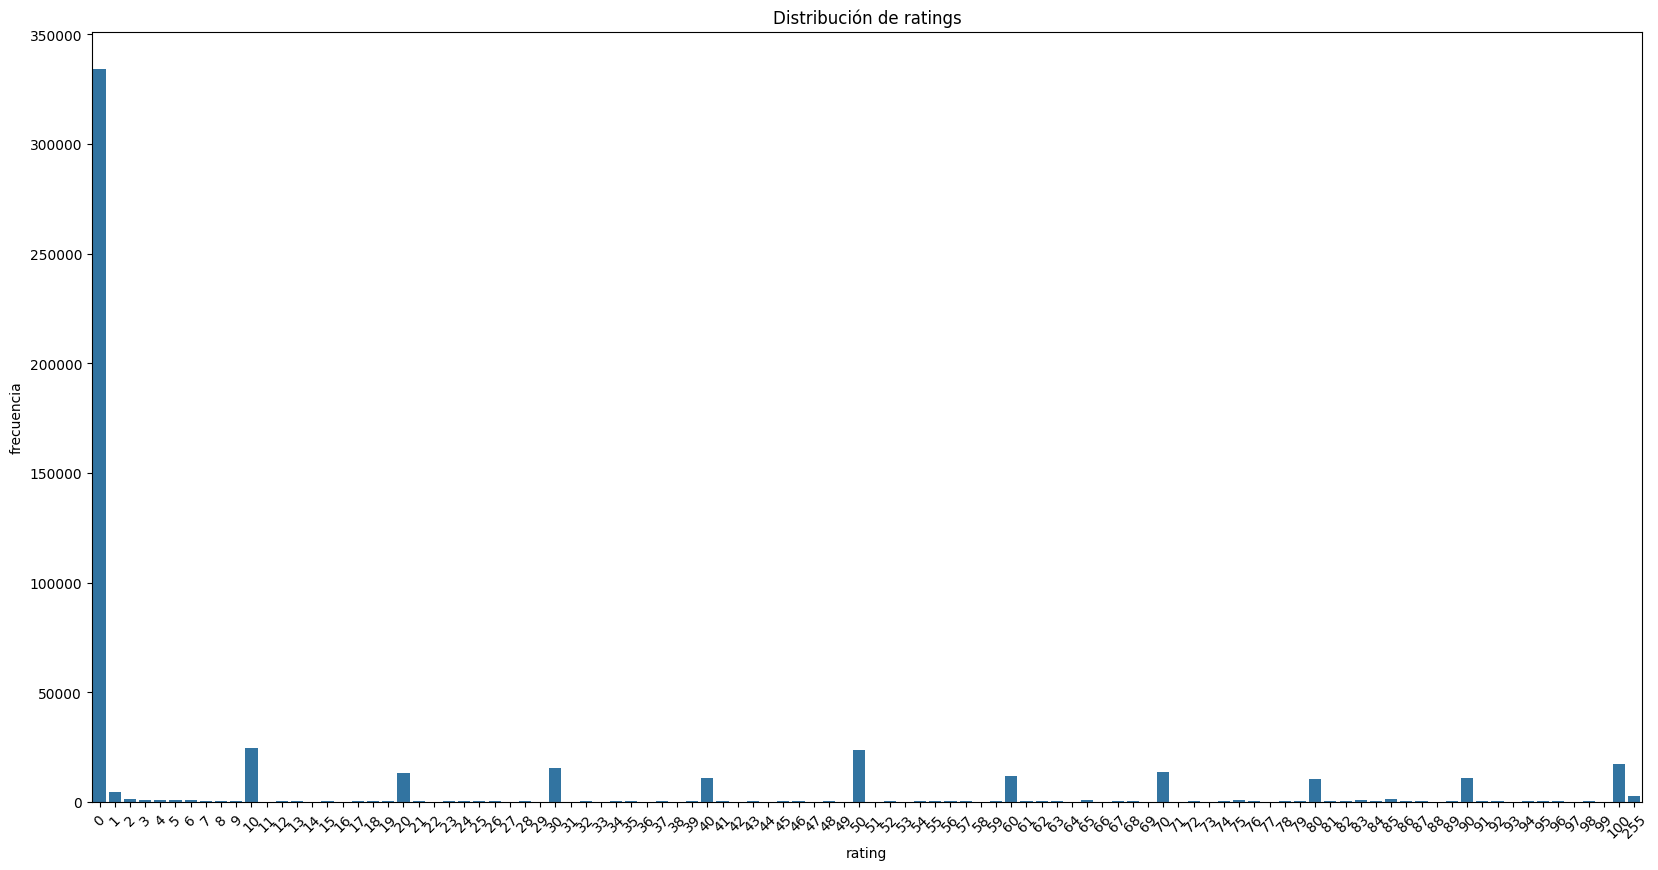

In [ ]:
# Este es el mismo gráfico que arriba, se notan mejor que son 101 valores, pero queda muy grande
plt.figure(figsize=(20, 10))
rating_counts = yahoo_train["rating"].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values)
plt.title("Distribución de ratings")
plt.xlabel("rating")
plt.ylabel("frecuencia")
plt.xticks(rotation=45)
plt.show()

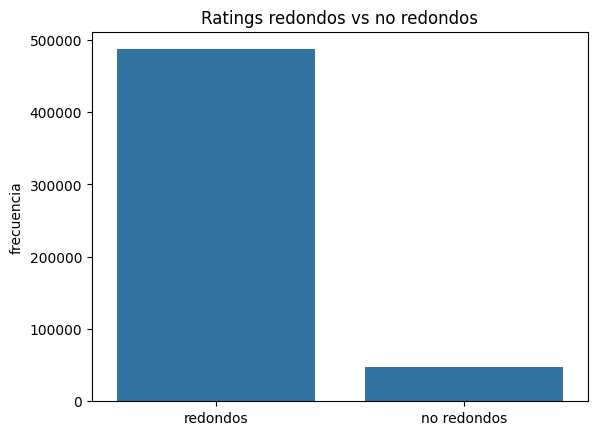

Redondos: 0.9110723724695448
No redondos: 0.08892762753045524


In [ ]:
plt.figure()
# la gran mayoría de los ratings son de números redondos, 0, 10, 20, ...
# nadie le pone de rating 27
round_ratings = yahoo_train[yahoo_train["rating"] % 10 == 0]["rating"].count()
non_round_ratings = yahoo_train[yahoo_train["rating"] % 10 != 0]["rating"].count()

frecuencia = [round_ratings, non_round_ratings]
valores = ["redondos", "no redondos"]

sns.barplot(x=valores, y=frecuencia)

plt.title("Ratings redondos vs no redondos")
plt.ylabel("frecuencia")

plt.show()

total = round_ratings + non_round_ratings

print("Redondos:", round_ratings / total)
print("No redondos:", non_round_ratings / total)

### Distribucion cantidad ratings por genero

In [ ]:
union_user_artist = yahoo_train.merge(yahoo_artists, on="artist_id")

genre_counts = union_user_artist.groupby("genre")["rating"].count()
genre_mean = union_user_artist.groupby("genre")["rating"].mean()

print(genre_counts.sort_values(ascending=False), end="\n\n")
print(genre_mean.sort_values(ascending=False))

genre
rock          170205
electronic    132804
pop            52452
folk           40890
country        34108
punk           28605
metal          23138
hiphop         14133
jazz            9528
blues           7996
soul            6657
latin           6153
classical       5301
reggae          1684
r&b              983
Name: rating, dtype: int64

genre
rock          22.989060
pop           20.874075
soul          20.612738
reggae        20.471496
hiphop        19.916295
metal         19.149192
jazz          18.947103
blues         18.306403
country       18.191568
electronic    17.726740
punk          17.406572
latin         17.168048
folk          16.168012
r&b           16.143438
classical     15.982833
Name: rating, dtype: float64


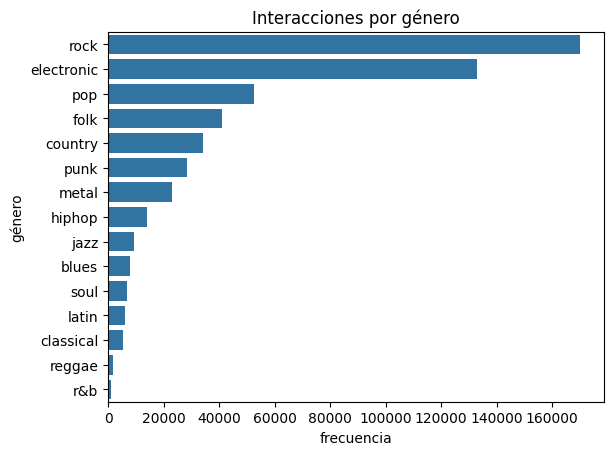

In [ ]:
plt.figure()

genre_counts_sorted = genre_counts.sort_values(ascending=False)

sns.barplot(x=genre_counts_sorted.values, y=genre_counts_sorted.index)

plt.title("Interacciones por género")
plt.xlabel("frecuencia")
plt.ylabel("género")

plt.show()

### Distribucion rating promedio por genero

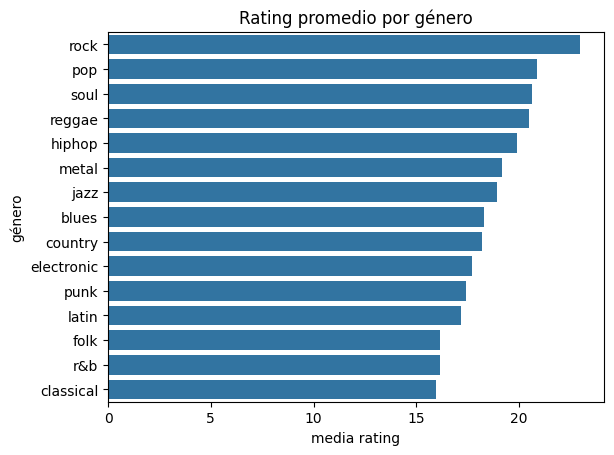

In [ ]:
plt.figure()

genre_mean_sorted = genre_mean.sort_values(ascending=False)

sns.barplot(x=genre_mean_sorted.values, y=genre_mean_sorted.index)

plt.title("Rating promedio por género")
plt.xlabel("media rating")
plt.ylabel("género")

plt.show()

## Datos Wikimedia

In [ ]:
wikimedia_train = pd.read_csv("Datos/wikimedia_train.csv", header=None)
wikimedia_train.columns = ["user_id", "item_id", "timestamp", 'evaluation']
wikimedia_train = wikimedia_train.iloc[1:]

wikimedia_validation = pd.read_csv("Datos/wikimedia_validation.csv", header=None)
wikimedia_validation.columns = ["user_id", "item_id", "timestamp", 'evaluation']
wikimedia_validation = wikimedia_validation.iloc[1:]

wikimedia_embeddings = np.load('Datos/wikimedia_image_embeddings.npy')

wikimedia_item_id_to_embedding_id = np.load('Datos/wikimedia_item_id_to_idx.npy', allow_pickle=True)

In [ ]:
wikimedia_train.describe()

,user_id,item_id,timestamp,evaluation
count,67806,67806,67806,67806
unique,1079,9526,59696,2
top,2524,201203120,1380218040,False
freq,2481,24,21,67798


In [ ]:
wikimedia_validation.describe()

,user_id,item_id,timestamp,evaluation
count,9694,9694,9694,9694
unique,1075,5473,8636,2
top,2524,201803100,1506325860,False
freq,351,9,17,9683


In [ ]:
wikimedia_embeddings.shape

(9526, 512)

### Distribucion evaluation

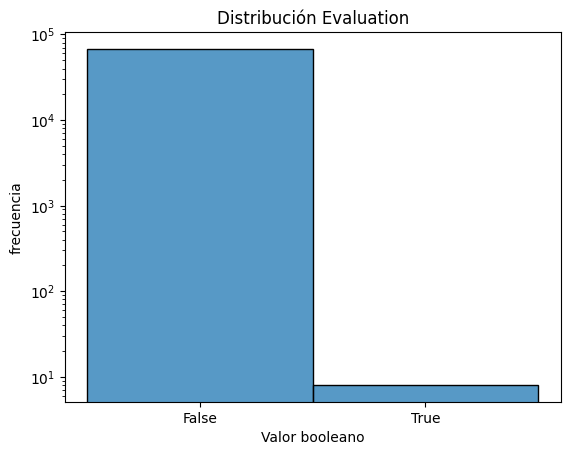

evaluation
False    67798
True         8
Name: count, dtype: int64


In [ ]:
plt.figure()
sns.histplot(wikimedia_train['evaluation'], bins=50)
plt.yscale('log')
plt.title("Distribución Evaluation")
plt.xlabel("Valor booleano")
plt.ylabel("frecuencia")
plt.show()

print(wikimedia_train['evaluation'].value_counts())

### Distribucion timestamp

In [ ]:
wikimedia_train['timestamp_not_unix'] = pd.to_datetime(wikimedia_train['timestamp'], unit='s')

/tmp/ipykernel_144/1872614142.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  wikimedia_train['timestamp_not_unix'] = pd.to_datetime(wikimedia_train['timestamp'], unit='s')


In [ ]:
wikimedia_train

,user_id,item_id,timestamp,evaluation,timestamp_not_unix
1,1,200502005,1108503300,False,2005-02-15 21:35:00
2,1,200504028,1113243060,False,2005-04-11 18:11:00
3,1,200504029,1113243060,False,2005-04-11 18:11:00
4,1,200504034,1113246480,False,2005-04-11 19:08:00
5,1,200504035,1113246600,False,2005-04-11 19:10:00
...,...,...,...,...,...
67802,7395,201904158,1555263120,False,2019-04-14 17:32:00
67803,7395,201904173,1555317600,False,2019-04-15 08:40:00
67804,7395,201904201,1555897200,False,2019-04-22 01:40:00
67805,7395,201904228,1556006940,False,2019-04-23 08:09:00


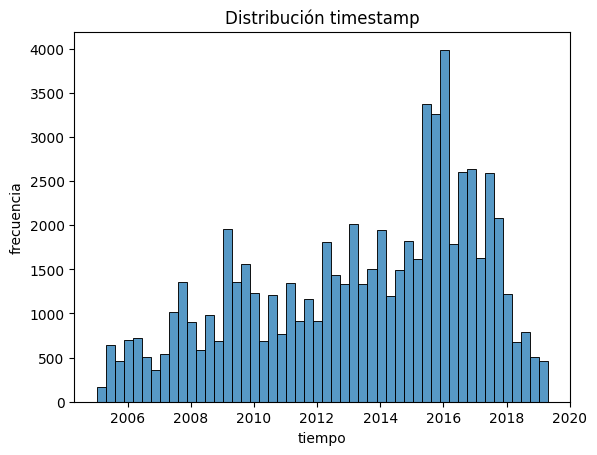

In [ ]:
plt.figure()
sns.histplot(wikimedia_train['timestamp_not_unix'], bins=50)
plt.title("Distribución timestamp")
plt.xlabel("tiempo")
plt.ylabel("frecuencia")
plt.show()
